In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.burgers import (
    BurgersMultiTrajectoryGLSConfig,
    generate_burgers_dataset,
    run_burgers_multi_trajectory_gls_experiment,
)
from mfsindy.cases.burgers_plots import COLORS_MODELS
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]

cfg = BurgersMultiTrajectoryGLSConfig(
    n_runs=5,
    results_dir=str(RESULTS_DIR),
    results_filename="burgers_part1_errors.csv",
)


# Burgers Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Burgers equation using the multi-trajectory (Part 1) workflow.

## Governing equations

The one-dimensional viscous Burgers equation is

$$
\partial_t u + u\partial_x u = \nu\partial_{xx} u,
$$

where $u(x,t)$ is the state variable and $\nu$ is the viscosity coefficient.

We use viscosity $\nu$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.

### Trajectory snapshot
Preview noisy LF/HF trajectories and a clean reference.

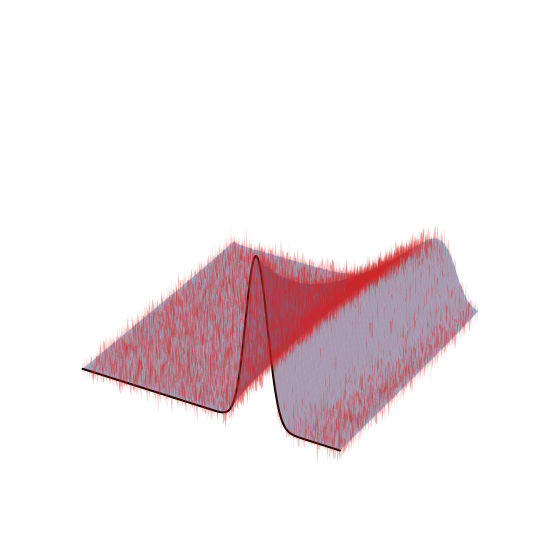

In [2]:
from mfsindy.cases.burgers_plots import plot_multifidelity_trajectories
X_ref, t_ref, x_ref,_ = generate_burgers_dataset(
    n_traj=1,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu
)

X_hf_noisy, _, _, _ = generate_burgers_dataset(
    n_traj=cfg.n_hf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=cfg.noise_hf_rel*np.std(X_ref),
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu
)

X_lf_noisy, _, _, _ = generate_burgers_dataset(
    n_traj=cfg.n_lf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=cfg.noise_lf_rel*np.std(X_ref),
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu
)
plot_multifidelity_trajectories(X_hf_noisy, X_lf_noisy, X_ref, x_ref, t_ref)


### Run

In [ ]:
(
    _df_errors,
    _mae_errors,
    _l0_errors,
    state_std,
    noise_hf_abs,
    noise_lf_abs,
) = run_burgers_multi_trajectory_gls_experiment(cfg)

errors_path = Path(cfg.results_dir) / cfg.results_filename
df_errors = pd.read_csv(errors_path)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)

print("Mean Absolute Error")
print(mae_summary)
print("Support Fraction Error")
print(l0_summary)


Running Part 1 Burgers experiment with n_LF=100, n_HF=10, noise_rel(LF)=0.25, noise_rel(HF)=0.01.


Monte Carlo Burgers MF: 100%|██████████| 5/5 [04:40<00:00, 56.11s/it]

         median       q25       q75
model                              
HF     0.000667  0.000603  0.000750
LF     0.001229  0.001074  0.001870
MF     0.001216  0.000930  0.001623
MF_w   0.000399  0.000303  0.000416
       median  q25  q75
model                  
HF        0.5  0.5  0.5
LF        0.5  0.5  0.5
MF        0.5  0.5  0.5
MF_w      0.0  0.0  0.0


### Error summaries
Bubble histograms summarise the MAE and $L_0$ distributions across methods.

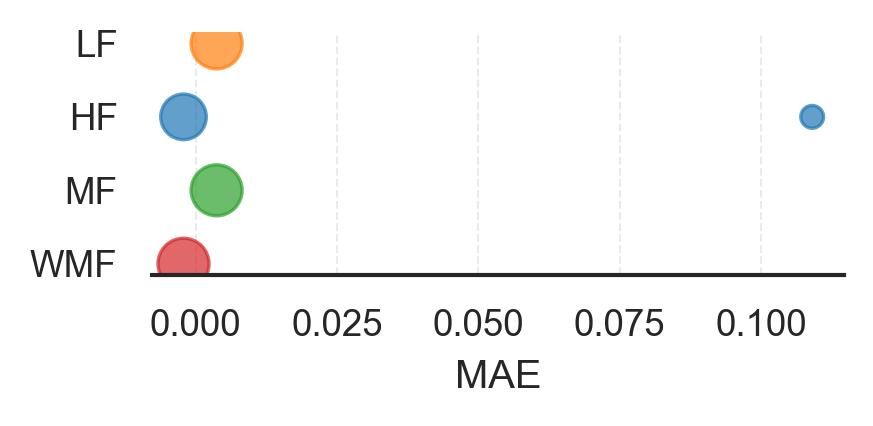

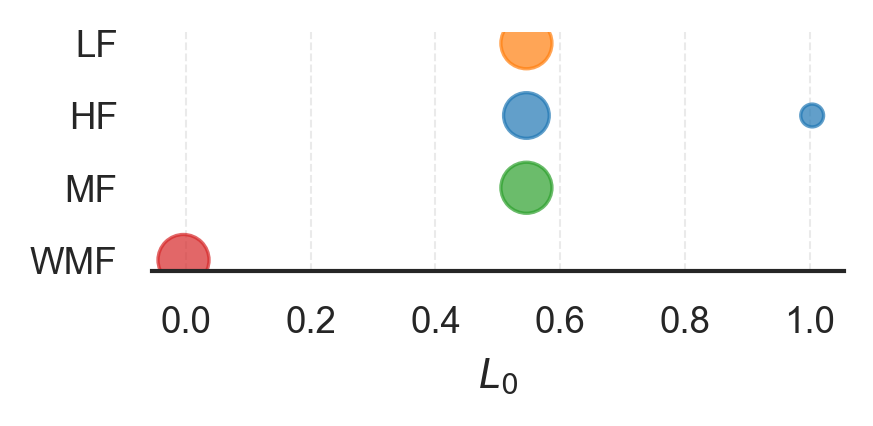

In [ ]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

